In [12]:
import sys, os
sys.path.append(os.path.abspath("."))

In [13]:
import torch
import torchvision.transforms as transforms
import numpy as np
from PIL import Image
from matplotlib import pyplot as plt

from segment_anything import sam_model_registry

from sam_lora import SamLoRA

In [14]:
print("cuda available: ", torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

cuda available:  True


In [ ]:
params = torch.load("SavedModels/sam_lora_finetuned_params_20251202_135452.pt")

print(f"Loaded {len(params)} named parameters and {sum(p.numel() for p in params.values())} total parameters from finetuned model")
for name, param in params.items():
    print(f"\n--- {name} --- ")
    print(f"shape: {param.shape}")
    print(f"max: {param.max().item()}, min: {param.min().item()}, std: {param.std().item()}")

SyntaxError: unterminated string literal (detected at line 1) (2193068130.py, line 1)

In [ ]:
sam_checkpoint = "/data/jhehli/model_checkpoints/sam_vit_b_01ec64.pth"
model_type = "vit_b"
sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device)

sam_lora = SamLoRA(sam, r=4, finetune_img_encoder=False,
                   finetune_mask_decoder=True, finetune_prompt_encoder=True)
sam_lora.to(device)
sam_lora.load_state_dict(params, strict=False)
sam_lora.eval()
print()

In [ ]:
def load_transform_image(path, resize=(1024, 1024)):
    transform = transforms.Compose([transforms.Resize(resize, interpolation=transforms.InterpolationMode.BILINEAR),
                                    transforms.ToTensor(),
                                    transforms.Lambda(lambda t: t.repeat(3, 1, 1) if t.shape[0] == 1 else t)])

    img = Image.open(path)
    return transform(img)


def show_mask(mask, ax):
    color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)


def get_batched_input_list(image: torch.Tensor):
    return [{
        "image": img,
        "original_size": (img.shape[1], img.shape[2])
    } for img in image.unsqueeze(0).unbind(0)]


def evaluate_on_image(image_path):
    input_img = load_transform_image(image_path).to(device)
    print(f"Input image shape: {input_img.shape}")

    input_list = get_batched_input_list(input_img)

    outputs = sam_lora(batched_input=input_list, multimask_output=False)
    mask = outputs[0]['masks'].squeeze(0).cpu().numpy()
    print(f"Output mask shape: {mask.shape}")
    print(f"Output mask dtype: {mask.dtype}")

    plt.figure(figsize=(10, 10))
    plt.imshow(input_img.permute(1, 2, 0).cpu().numpy())
    show_mask(mask, plt.gca())
    plt.axis('off')
    plt.show()

    return mask

Input image shape: torch.Size([3, 1024, 1024])
Output mask shape: (1, 1024, 1024)
Output mask dtype: bool


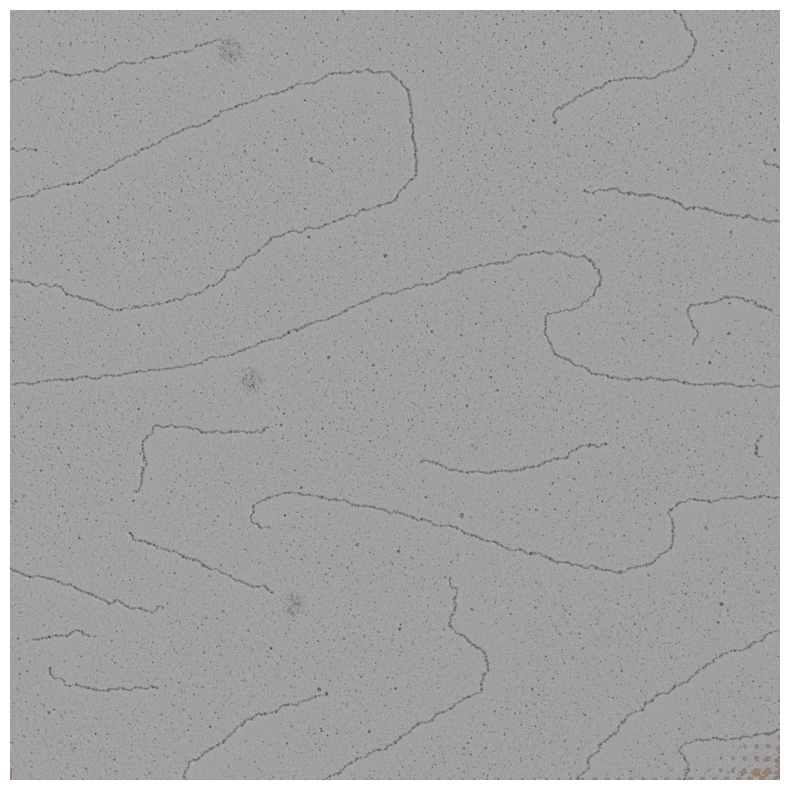

In [ ]:
mask1 = evaluate_on_image("/data/jhehli/datasets/SAM_LoRA_Augmented/test/images/20250811_dani_vegetariana_soi_2_bottom_rot270.png")

Input image shape: torch.Size([3, 1024, 1024])
Output mask shape: (1, 1024, 1024)
Output mask dtype: bool


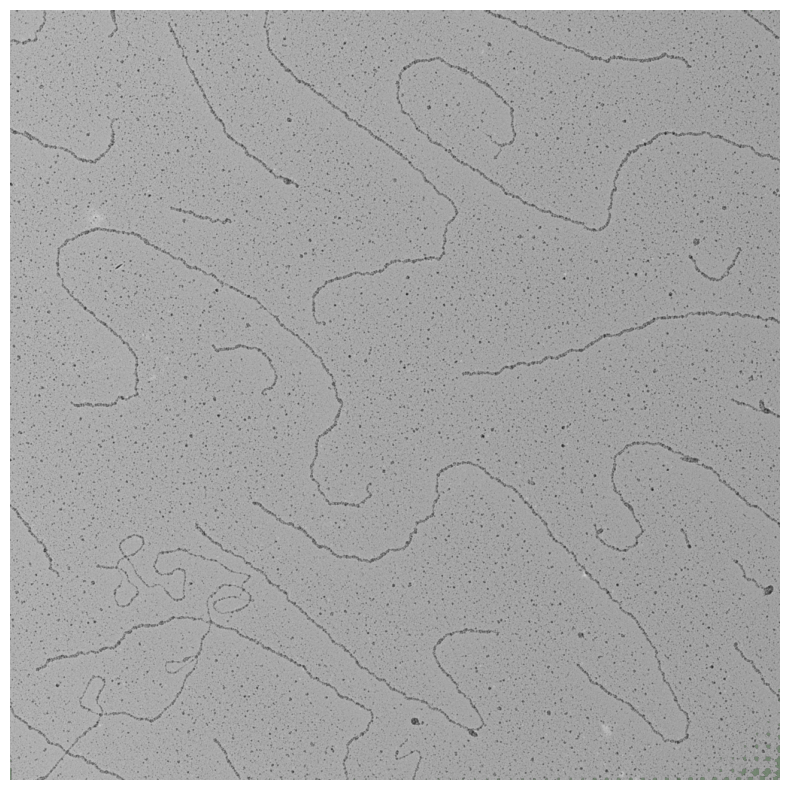

In [ ]:
mask2 = evaluate_on_image("/data/jhehli/datasets/SAM_LoRA_Augmented/test/images/20240523_andrea_orange_soi_2_center_rot270.png")

In [ ]:
print(f"{(mask1 == mask2).sum()} of {mask1.size} pixels are equal between the two masks.")
print(f"{(mask1 != mask2).sum()} of {mask1.size} pixels are different between the two masks.")

1048501 of 1048576 pixels are equal between the two masks.
75 of 1048576 pixels are different between the two masks.


Input image shape: torch.Size([3, 1024, 1024])
Output mask shape: (1, 1024, 1024)
Output mask dtype: bool


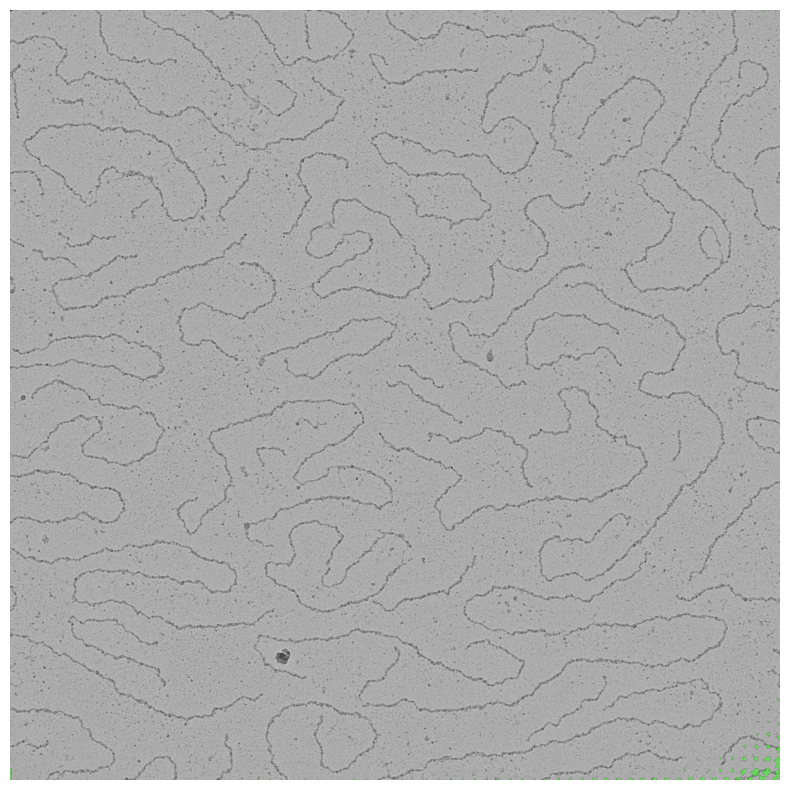

In [ ]:
mask3 = evaluate_on_image("/data/jhehli/additional_data/20240425_andrea_lila_soi_2_bottom.png")

Input image shape: torch.Size([3, 512, 512])


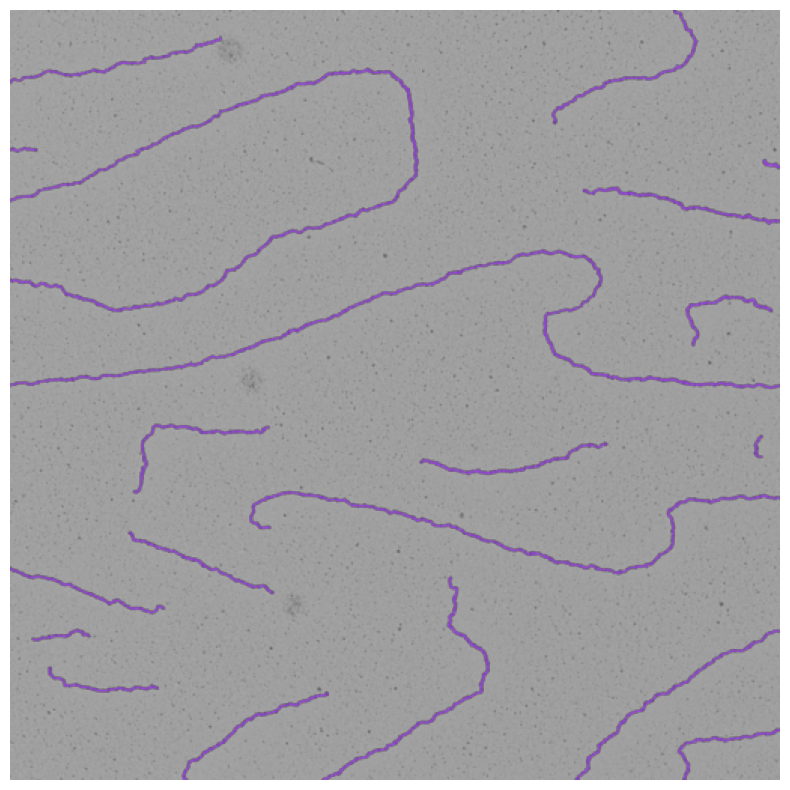

In [ ]:
import torch.nn.functional as F

lowres_size = (512, 512)


def load_transform_lowres_mask(path):
    transform = transforms.Compose([transforms.Resize((1024, 1024), interpolation=transforms.InterpolationMode.BILINEAR),
                                    transforms.ToTensor()])
    img = Image.open(path)
    img = transform(img)

    img = img.to(dtype=torch.float32).unsqueeze(0)
    img = F.interpolate(img, size=lowres_size,
                        mode='bilinear', align_corners=False)
    return img.squeeze(0).cpu().numpy()


def plot_lowres_groundtruth(image_path):
    input_img = load_transform_image(image_path, resize=lowres_size)
    print(f"Input image shape: {input_img.shape}")

    mask = load_transform_lowres_mask(image_path.replace("images", "masks"))

    plt.figure(figsize=(10, 10))
    plt.imshow(input_img.permute(1, 2, 0).cpu().numpy())
    show_mask(mask, plt.gca())
    plt.axis('off')
    plt.show()


plot_lowres_groundtruth(
    "/data/jhehli/datasets/SAM_LoRA_Augmented/test/images/20250811_dani_vegetariana_soi_2_bottom_rot270.png")